In [529]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_regression

import os, time, requests, pandas as pd
from dateutil.relativedelta import relativedelta

import statsmodels.api as sm

In [224]:
# Data Load
riv_pm_25 = pd.read_csv("data/rivian_normal_IL_US_pm25.csv")
riv_viirs = pd.read_csv("data/rivian_viirs_2yrs.csv")
riv_revenue = pd.read_csv("data/rivian_quarterly_revenue.csv")

# Data Preprocess
riv_pm_25.columns = riv_pm_25.columns.str.strip()
riv_pm_25['date'] = pd.to_datetime(riv_pm_25['date'], format='%Y/%m/%d')
riv_pm_25 = riv_pm_25[riv_pm_25["pm25"].notna() & (riv_pm_25["pm25"] != " ")]
riv_pm_25['pm25'] = riv_pm_25['pm25'].astype(int)

riv_viirs['date'] = pd.to_datetime(riv_viirs['date'], format='%Y-%m-%d')

In [91]:
riv_pm_25.head()

,date,pm25,o3
0,2025-10-01,39,54
1,2025-10-02,41,44
2,2025-10-03,40,44
3,2025-10-04,49,36
4,2025-10-05,28,31


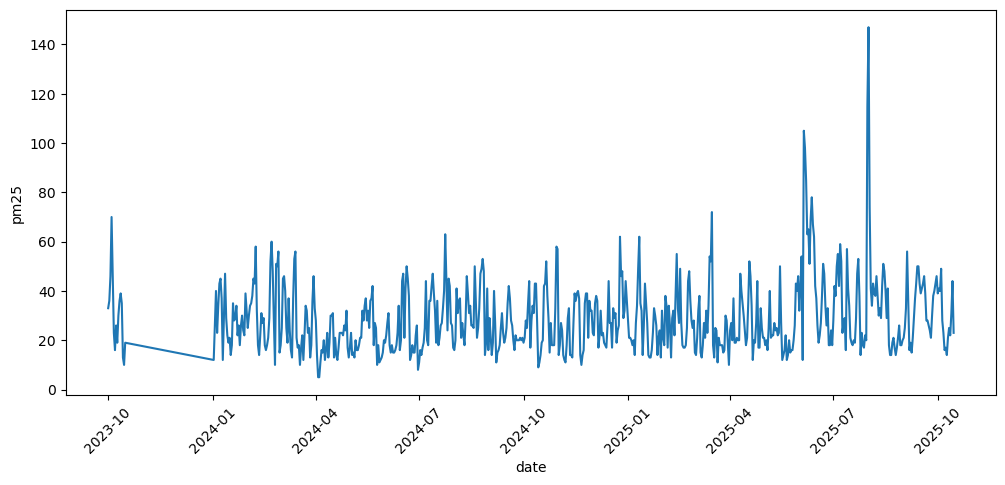

In [105]:
plt.figure(figsize=(12,5))
sns.lineplot(data=riv_pm_25.loc[:665], x='date', y='pm25')

plt.xticks(rotation=45)
plt.show()

# Stock Price Data

In [127]:
API_KEY = '8ELKK22IVY1NO9UC'

# Adj data not available for free
params = {
    "function": "TIME_SERIES_DAILY",
    "symbol": "RIVN",
    "outputsize": "full",
    "apikey": API_KEY,
}
url = "https://www.alphavantage.co/query"

# Limited API calls, use sparingly
# r = requests.get(url, params=params, timeout=30)

In [ ]:
ts = r.json()["Time Series (Daily)"]
rivn = (pd.DataFrame.from_dict(ts, orient="index")
        .rename(columns={
            "1. open": "open",
            "2. high": "high",
            "3. low": "low",
            "4. close": "close",
            "5. volume": "volume",
        })
        .apply(pd.to_numeric)
        .sort_index())
rivn.reset_index(inplace=True)
rivn.rename(columns={'index': 'date'}, inplace=True)
rivn['date'] = pd.to_datetime(rivn['date'], format='%Y-%m-%d')
# rivn.to_csv('data/rivn_ticker_2yrs.csv')
rivn

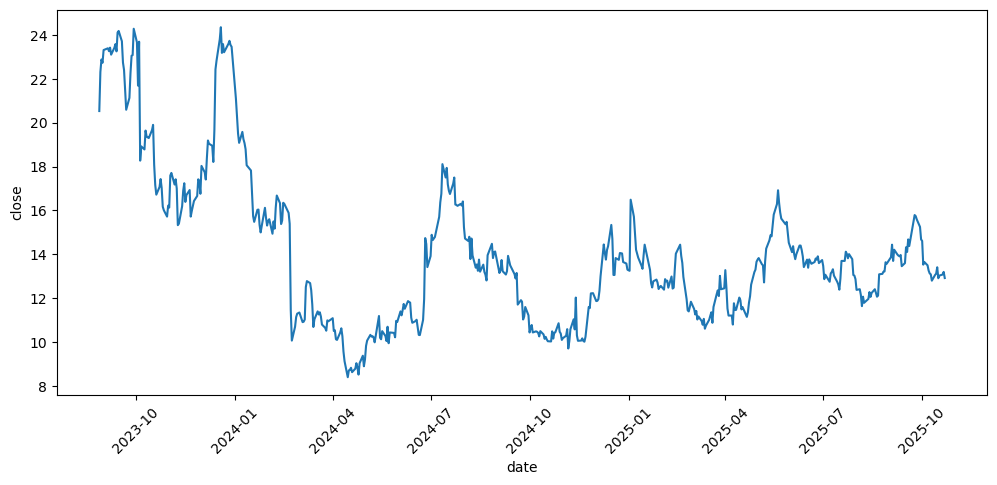

In [180]:
plt.figure(figsize=(12,5))
sns.lineplot(data=rivn[450:], x='date', y='close')

plt.xticks(rotation=45)
plt.show()

In [465]:
riv_pm_25.sort_values('date').tail(60)

,date,pm25,o3
62,2025-08-17,29,39
63,2025-08-18,41,27
64,2025-08-19,18,31
65,2025-08-20,14,41
66,2025-08-21,14,31
67,2025-08-22,19,26
68,2025-08-23,21,22
69,2025-08-24,17,22
70,2025-08-25,14,27
71,2025-08-26,17,29


# Combine VIIRS, PM25, RIVN

In [467]:
mg1 = riv_pm_25.merge(riv_viirs, on='date', how='left').sort_values('date').reset_index(drop=True)
df = mg1.merge(rivn, on='date', how='left')[['date', 'pm25', 'radiance', 'close']][2451:].reset_index(drop=True)

In [469]:
df[["close","pm25","radiance"]].corr()

,close,pm25,radiance
close,1.000000,0.103806,0.075167
pm25,0.103806,1.000000,-0.043873
radiance,0.075167,-0.043873,1.000000


In [565]:
#### Consider correlation with a lag
# radiance leading price by 1 day
df["pm25_lead14"] = df["pm25"].shift(14)
df["pm25_lead21"] = df["pm25"].shift(21)
df["pm25_lead28"] = df["pm25"].shift(28)
df["pm25_lead35"] = df["pm25"].shift(35)
df["pm25_lead42"] = df["pm25"].shift(42)
df['close_chg'] = df['close'].pct_change()
df[["pm25","radiance",'close', "pm25_lead14", 'pm25_lead21', 'pm25_lead28', 'pm25_lead35', 'pm25_lead42', 'close_chg']].corr()

/var/folders/7n/r66735gn7xx2tdk0357s_k_m0000gn/T/ipykernel_90500/3529031398.py:8: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['close_chg'] = df['close'].pct_change()


,pm25,radiance,close,pm25_lead14,pm25_lead21,pm25_lead28,pm25_lead35,pm25_lead42,close_chg
pm25,1.000000,-0.043873,0.103806,0.025721,-0.011076,0.066981,0.027693,-0.029192,-0.088546
radiance,-0.043873,1.000000,0.075167,0.054820,0.071752,-0.018339,0.019466,-0.056381,0.047147
close,0.103806,0.075167,1.000000,0.099313,0.081483,0.064615,0.056666,0.068060,0.072191
pm25_lead14,0.025721,0.054820,0.099313,1.000000,0.127456,0.019730,-0.010656,0.068122,-0.053530
pm25_lead21,-0.011076,0.071752,0.081483,0.127456,1.000000,0.128920,0.013601,-0.005399,0.007401
pm25_lead28,0.066981,-0.018339,0.064615,0.019730,0.128920,1.000000,0.126614,0.010812,0.017217
pm25_lead35,0.027693,0.019466,0.056666,-0.010656,0.013601,0.126614,1.000000,0.130986,0.000692
pm25_lead42,-0.029192,-0.056381,0.068060,0.068122,-0.005399,0.010812,0.130986,1.000000,-0.019021
close_chg,-0.088546,0.047147,0.072191,-0.053530,0.007401,0.017217,0.000692,-0.019021,1.000000


In [475]:
df[["pm25","radiance",'close', "pm25_lead14", 'pm25_lead21', 'pm25_lead28', 'pm25_lead35', 'pm25_lead42']].corr('spearman')

,pm25,radiance,close,pm25_lead14,pm25_lead21,pm25_lead28,pm25_lead35,pm25_lead42
pm25,1.000000,-0.047914,0.197497,0.024527,0.004067,0.066963,0.045365,-0.063887
radiance,-0.047914,1.000000,0.065790,0.032002,0.057216,-0.025161,0.056657,-0.049325
close,0.197497,0.065790,1.000000,0.179155,0.130360,0.075561,0.064947,0.067302
pm25_lead14,0.024527,0.032002,0.179155,1.000000,0.103278,0.015020,0.004904,0.067581
pm25_lead21,0.004067,0.057216,0.130360,0.103278,1.000000,0.102298,0.004470,0.011482
pm25_lead28,0.066963,-0.025161,0.075561,0.015020,0.102298,1.000000,0.096912,0.002988
pm25_lead35,0.045365,0.056657,0.064947,0.004904,0.004470,0.096912,1.000000,0.101095
pm25_lead42,-0.063887,-0.049325,0.067302,0.067581,0.011482,0.002988,0.101095,1.000000


In [477]:
df[["pm25","radiance",'close', "pm25_lead14", 'pm25_lead21', 'pm25_lead28', 'pm25_lead35', 'pm25_lead42']].corr('kendall')

,pm25,radiance,close,pm25_lead14,pm25_lead21,pm25_lead28,pm25_lead35,pm25_lead42
pm25,1.000000,-0.033360,0.134647,0.017780,0.003223,0.045611,0.030626,-0.042993
radiance,-0.033360,1.000000,0.044614,0.022751,0.038615,-0.018349,0.037667,-0.031454
close,0.134647,0.044614,1.000000,0.118475,0.087488,0.049795,0.043379,0.044670
pm25_lead14,0.017780,0.022751,0.118475,1.000000,0.070489,0.010887,0.003825,0.046123
pm25_lead21,0.003223,0.038615,0.087488,0.070489,1.000000,0.069910,0.003422,0.008354
pm25_lead28,0.045611,-0.018349,0.049795,0.010887,0.069910,1.000000,0.066360,0.002316
pm25_lead35,0.030626,0.037667,0.043379,0.003825,0.003422,0.066360,1.000000,0.069314
pm25_lead42,-0.042993,-0.031454,0.044670,0.046123,0.008354,0.002316,0.069314,1.000000


In [483]:
# standardize features
df["close_chg"] = df["close"].pct_change()
df["pm25_chg"]  = df["pm25"].pct_change()
df["rad_chg"]   = df["radiance"].pct_change()

for c in ["close_chg","pm25_chg","rad_chg"]:
    df[c] = (df[c] - df[c].mean()) / df[c].std()

df[['pm25',"pm25_chg","radiance",'rad_chg','close', 'close_chg', "pm25_lead14", 'pm25_lead21']].corr()

/var/folders/7n/r66735gn7xx2tdk0357s_k_m0000gn/T/ipykernel_90500/3403727331.py:2: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df["close_chg"] = df["close"].pct_change()
/var/folders/7n/r66735gn7xx2tdk0357s_k_m0000gn/T/ipykernel_90500/3403727331.py:4: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df["rad_chg"]   = df["radiance"].pct_change()


,pm25,pm25_chg,radiance,rad_chg,close,close_chg,pm25_lead14,pm25_lead21
pm25,1.000000,0.433429,-0.043873,-0.047381,0.103806,-0.088546,0.025721,-0.011076
pm25_chg,0.433429,1.000000,0.001089,0.004886,0.019698,-0.010810,-0.012946,0.029980
radiance,-0.043873,0.001089,1.000000,0.031261,0.075167,0.047147,0.054820,0.071752
rad_chg,-0.047381,0.004886,0.031261,1.000000,-0.029914,0.030853,-0.041146,0.060845
close,0.103806,0.019698,0.075167,-0.029914,1.000000,0.072191,0.099313,0.081483
close_chg,-0.088546,-0.010810,0.047147,0.030853,0.072191,1.000000,-0.053530,0.007401
pm25_lead14,0.025721,-0.012946,0.054820,-0.041146,0.099313,-0.053530,1.000000,0.127456
pm25_lead21,-0.011076,0.029980,0.071752,0.060845,0.081483,0.007401,0.127456,1.000000


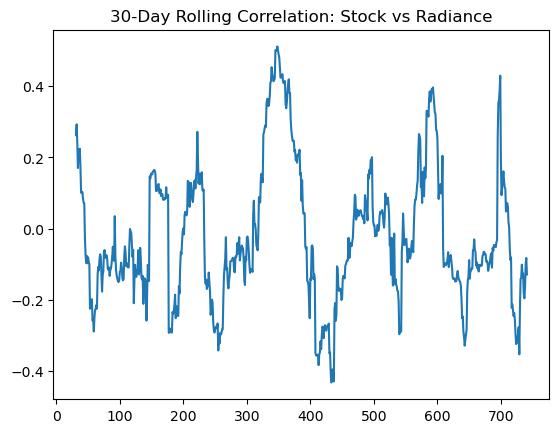

In [322]:
window = 30  # days
rolling_corr = (
    df["close_chg"]
    .rolling(window)
    .corr(df["pm25_chg"])
    .rename("corr_pm25")
)
rolling_corr.plot(title="30-Day Rolling Correlation: Stock vs Radiance")
plt.show()

In [577]:
# Test for non-linear dependence w 14 day lag

# drop NaNs
df_nona = df[['pm25', 'close']].dropna()
X = df_nona[['pm25']].shift(14).dropna()
y = df_nona.loc[X.index, 'close']

mi = mutual_info_regression(X.values.reshape(-1,1), y, random_state=0)
print(dict(zip(X.columns, mi)))

{'pm25': 0.03306962781655942}


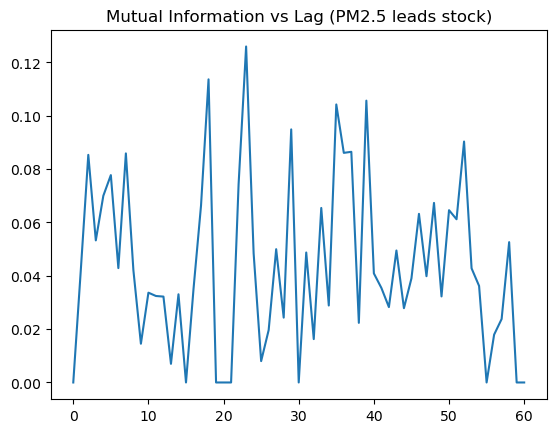

In [583]:
# Find best lag
lags = range(0, 61)   # test 0–60 day leads
mi_scores = []

for k in lags:
    # shift PM2.5 forward by k days so it “leads” the stock
    X = df_nona['pm25'].shift(k).dropna().values.reshape(-1,1)
    y = df_nona.loc[df_nona['pm25'].shift(k).dropna().index, 'close']
    mi = mutual_info_regression(X, y, random_state=0)[0]
    mi_scores.append(mi)

pd.Series(mi_scores, index=lags).plot(title="Mutual Information vs Lag (PM2.5 leads stock)")
plt.show()

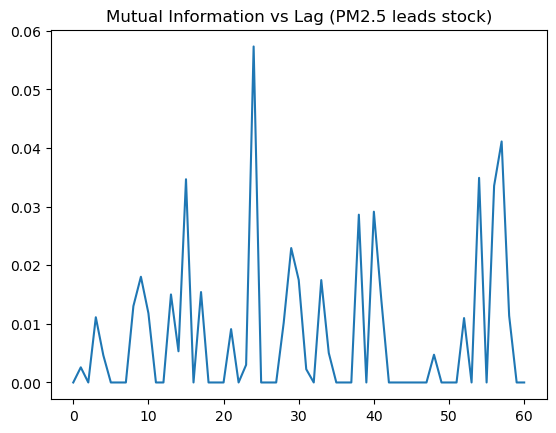

In [585]:
lags = range(0, 61)   # test 0–60 day leads
mi_scores_chg = []

chg_df = df[['pm25', 'close_chg']].dropna()

for k in lags:
    # shift PM2.5 forward by k days so it “leads” the stock
    X = chg_df['pm25'].shift(k).dropna().values.reshape(-1,1)
    y = chg_df.loc[chg_df['pm25'].shift(k).dropna().index, 'close_chg']
    mi = mutual_info_regression(X, y, random_state=0)[0]
    mi_scores_chg.append(mi)

pd.Series(mi_scores_chg, index=lags).plot(title="Mutual Information vs Lag (PM2.5 leads stock)")
plt.show()

In [593]:
lag = mi_scores.index(max(mi_scores))
lag_chg = mi_scores_chg.index(max(mi_scores_chg))
print(f'When considering percent change in stock (return), a lag of {lag_chg} captures the lag best.')

When considering percent change in stock (return), a lag of 24 captures the lag best.


In [497]:
# Dependence with 25 lag:
X = df_nona['pm25'].shift(lag).dropna().values.reshape(-1,1)
y = df_nona.loc[df_nona['pm25'].shift(lag).dropna().index, 'close']
mi = mutual_info_regression(X, y, random_state=0)[0]
print(f'Best mi score of {mi} reached at lag of {lag}.')

Best mi score of 0.12598993580355922 reached at lag of 23.


<Axes: title={'center': 'Rolling MI (PM25 lead 23 days)'}>

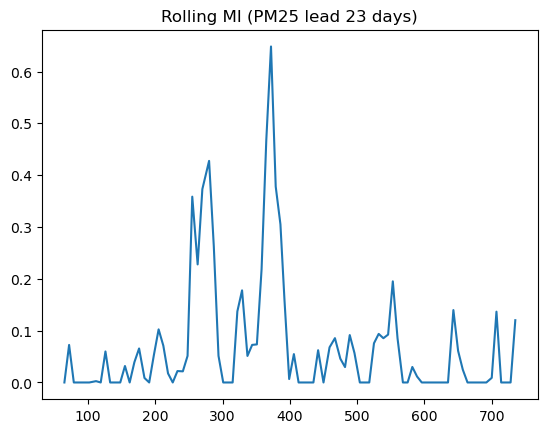

In [595]:
df['pm25_lead23'] = df['pm25'].shift(23)
df['pm25_lead24'] = df['pm25'].shift(24)
df_lag_nona = df[['pm25_lead23', 'close']].dropna()
mi_rolling = rolling_mutual_info(df_lag_nona['pm25_lead23'], df_lag_nona['close'], window=30)
mi_rolling.plot(title="Rolling MI (PM25 lead 23 days)")

<Axes: title={'center': 'Rolling MI (PM25 lead 23 days)'}>

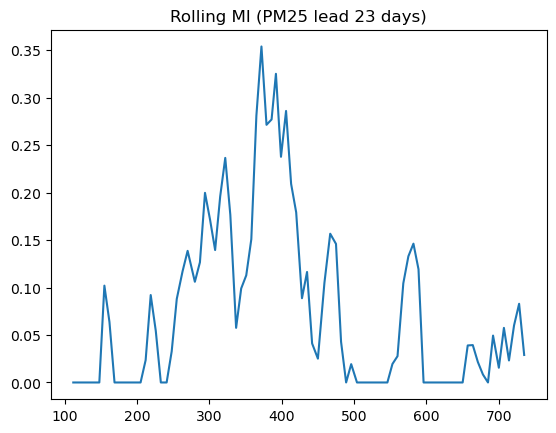

In [526]:
df['pm25_lead23'] = df['pm25'].shift(23)
df_lag_nona = df[['pm25_lead23', 'close']].dropna()
mi_rolling = rolling_mutual_info(df_lag_nona['pm25_lead23'], df_lag_nona['close'], window=60)
mi_rolling.plot(title="Rolling MI (PM25 lead 23 days)")

# Initial Models

In [573]:
X = sm.add_constant(df[['pm25_lead23','close_chg']].dropna()[['pm25_lead23']])
y = df.loc[X.index, 'close_chg']
ols = sm.OLS(y, X).fit()
print(ols.summary())

                            OLS Regression Results                            
Dep. Variable:              close_chg   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     2.201
Date:                Thu, 23 Oct 2025   Prob (F-statistic):              0.138
Time:                        00:39:33   Log-Likelihood:                 1380.2
No. Observations:                 719   AIC:                            -2756.
Df Residuals:                     717   BIC:                            -2747.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.0043      0.003      1.429      

In [597]:
X = sm.add_constant(df[['pm25_lead24','close_chg']].dropna()[['pm25_lead24']])
y = df.loc[X.index, 'close_chg']
ols = sm.OLS(y, X).fit()
print(ols.summary())

                            OLS Regression Results                            
Dep. Variable:              close_chg   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.5847
Date:                Thu, 23 Oct 2025   Prob (F-statistic):              0.445
Time:                        00:47:09   Log-Likelihood:                 1377.1
No. Observations:                 718   AIC:                            -2750.
Df Residuals:                     716   BIC:                            -2741.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.0023      0.003      0.774      

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

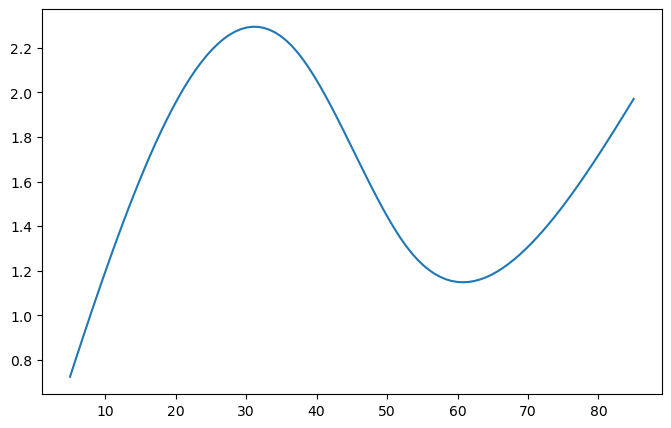

In [613]:
XX = gam.generate_X_grid(term=0)  # grid over pm25_lead23
pdep, confi = gam.partial_dependence(term=0, X=XX, width=0.95)

plt.figure(figsize=(8,5))
plt.plot(XX[:, 0], pdep, label='Partial dependence (s(0))')
plt.fill_between(XX[:, 0], confi[0][:, 0], confi[0][:, 1], alpha=0.2)
plt.xlabel('pm25_lead23')
plt.ylabel('Predicted close')
plt.title('GAM Partial Dependence: s(0) on pm25_lead23')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

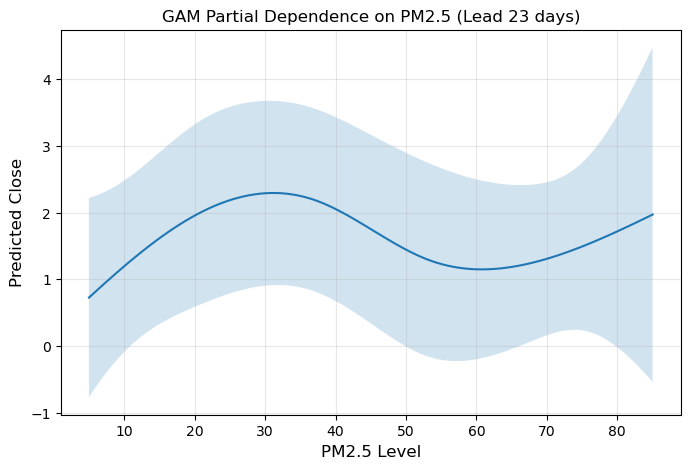

In [621]:
import seaborn as sns
XX = gam.generate_X_grid(term=0)                 # shape (n, 1)
pdep, confi = gam.partial_dependence(term=0, X=XX, width=0.95)

# Handle both possible confi shapes:
# (n, 2) -> columns are [lower, upper]
# (2, n) -> rows are [lower, upper]
if confi.ndim == 2 and confi.shape[1] == 2:
    lower, upper = confi[:, 0], confi[:, 1]
elif confi.ndim == 2 and confi.shape[0] == 2:
    lower, upper = confi[0, :], confi[1, :]
else:
    # fallback if a different shape shows up
    raise ValueError(f"Unexpected confidence interval shape: {confi.shape}")

plt.figure(figsize=(8,5))
plt.plot(XX[:, 0], pdep, label='Partial dependence (s(0))')
plt.fill_between(XX[:, 0], lower, upper, alpha=0.2)
plt.xlabel('PM2.5 Level', fontsize=12)
plt.ylabel('Predicted Close', fontsize=12)
plt.title('GAM Partial Dependence on PM2.5 (Lead 23 days)')
plt.grid(True, alpha=0.3)
plt.show()


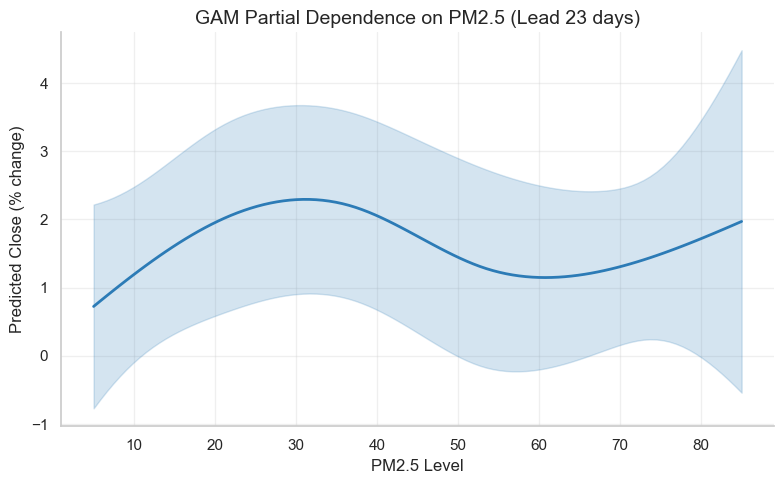

In [627]:
# Combine everything into a tidy DataFrame for seaborn
plot_df = pd.DataFrame({
    'PM2.5 Level': XX[:, 0],
    'Predicted Close': pdep,
    'Lower': lower,
    'Upper': upper
})

# Create figure
plt.figure(figsize=(8, 5))
sns.set_theme(style="whitegrid")

# Plot central curve
sns.lineplot(
    data=plot_df,
    x='PM2.5 Level',
    y='Predicted Close',
    color='#2C7BB6',  # deep blue tone
    linewidth=2
)

# Shaded confidence region
plt.fill_between(
    plot_df['PM2.5 Level'],
    plot_df['Lower'],
    plot_df['Upper'],
    color='#2C7BB6',
    alpha=0.2
)

# Style adjustments
plt.xlabel('PM2.5 Level', fontsize=12)
plt.ylabel('Predicted Close (% change)', fontsize=12)
plt.title('GAM Partial Dependence on PM2.5 (Lead 23 days)', fontsize=14)
plt.grid(True, alpha=0.3)
sns.despine()  # remove top/right borders
plt.tight_layout()
plt.show()
